In [5]:
%pip install odoorpc pandas matplotlib

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ----------------------------- ---------- 7.3/9.9 MB 38.1 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 25.2 MB/s  0:00:00
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ----------------- ---------------------- 3.7/8.3 MB 17.6 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.3 MB 15.7 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 14.8 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 24.0 MB/s  0:00:00
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   ----------- ---------------------------- 3.7/12.4 MB 16.9 MB/s eta 0:00:01
   --------------------- ------------------ 6.6/12.4 MB 15.7 MB/s eta 0:00:01
   ------------------------------ --------- 9.4/12.4 MB 15.2 MB/s eta 0:00:01
   ---------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import odoorpc
import pandas as pd
import matplotlib.pyplot as plt

# Conectamos con tu Odoo
# Si usas Docker o localhost, la IP suele ser '127.0.0.1'
odoo = odoorpc.ODOO('localhost', port=8069)

# Sustituye 'fncv' por el nombre real de tu base de datos
odoo.login('fncv', 'admin', '1234') 

print("Conexión establecida con el usuario:", odoo.env.user.name)

Conexión establecida con el usuario: Mitchell Admin


In [7]:
# Buscamos los resultados de las pruebas
# IMPORTANTE: Asegúrate de que el modelo se llama así en tu Odoo
ModeloResultados = odoo.env['natacion.result']
res_ids = ModeloResultados.search([])

# Leemos los campos que queremos analizar
# 'swimmer' suele ser un Many2one, OdooRPC nos traerá [id, nombre]
raw_data = ModeloResultados.read(res_ids, ['swimmer', 'time'])

# Limpiamos los datos para que Pandas los entienda bien
clean_data = []
for r in raw_data:
    clean_data.append({
        'Nadador': r['swimmer'][1] if r['swimmer'] else 'Anónimo',
        'Tiempo': r['time']
    })

# Creamos la tabla (DataFrame)
df = pd.DataFrame(clean_data)
print("Tabla de datos recuperada:")
print(df.head()) # Muestra las primeras 5 filas

Tabla de datos recuperada:
                  Nadador  Tiempo
0                 Anónimo     0.0
1                 Anónimo     0.0
2  Abdellah Alonso Blanca    10.0
3   Adoracion Pares Lopez    30.0
4  Agusti Gonzalez Garcia     5.0


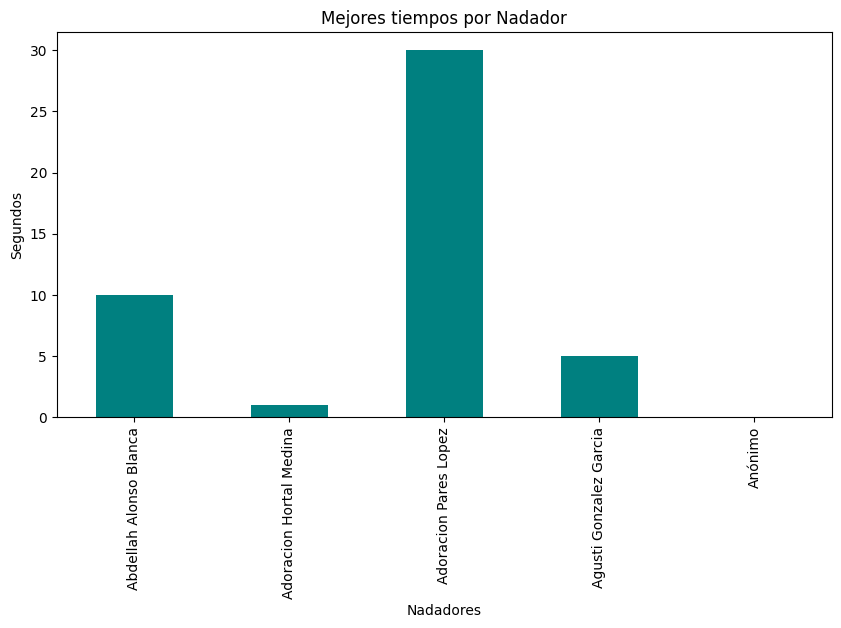

In [8]:
if not df.empty:
    # Agrupamos por nadador y sacamos su mejor tiempo (mínimo)
    mejores_tiempos = df.groupby('Nadador')['Tiempo'].min()
    
    # Dibujamos
    mejores_tiempos.plot(kind='bar', figsize=(10,5), color='teal')
    plt.title('Mejores tiempos por Nadador')
    plt.xlabel('Nadadores')
    plt.ylabel('Segundos')
    plt.show()
else:
    print("No hay datos en Odoo para mostrar la gráfica.")